# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'
#mod='t0zero'
#mode=sys.argv[2]
GM0 = 2.79284356
GE0 = 1

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GE0 = 1
GM0 = 2.792847356
GEp0 = 1
GMp0 = 2.792847356
GEn0 = 1
GMn0 = -1.91304272
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load World+Pol+Mainz Sum-Rules baseline Fitting Results

In [4]:
fit_date='may23'

In [5]:
##Load Q2max=1000 Fitting results#{{{
folder = '../%s_all_FF/z'%fit_date+str(kmax) # folder containing central fits
#filename=folder+'/Round6_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
Z = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err = np.zeros(N, dtype=float)
GM_err = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)
GE_err_rat = np.zeros(N, dtype=float)
GM_err_rat = np.zeros(N, dtype=float)
GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
    Z[i]=float(values[1])

    GE_fit[i]=float(values[2])
    GE_pos[i]=float(values[2])+abs(float(values[3]))
    GE_neg[i]=float(values[2])-abs(float(values[3]))
    GM_fit[i]=float(values[4])
    GM_pos[i]=float(values[4])+abs(float(values[5]))
    GM_neg[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat[i]=float(values[6])
    GE_pos_rat[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat[i]=float(values[8])
    GM_pos_rat[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat[i]=float(values[10])+abs(GEGM_err1)
    GEGM_neg_rat[i]=float(values[10])-abs(GEGM_err1)
 
    GEd[i] = GD(Q2[i]) * GE0
    GMd[i] = GD(Q2[i]) * GM0
    GE_err[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err[i] = GEGM_err1/float(values[10])
    GE_err_rat[i] = abs(float(values[7]) ) #/ abs(float(values[2]))
    GM_err_rat[i] = abs(float(values[9]) ) #/ abs(float(values[4]))
    
values = fitlines[2016].split()
erad = float(values[0])
derad = float(values[1])
mrad = float(values[2])
dmrad = float(values[3])

values = fitlines[2015].split()
ndof = float(values[0])
num_tot = float(values[1])
num_Mainz = float(values[2])
num_world = float(values[3])
num_pol = float(values[4])

values = fitlines[2014].split()
redchi2 = float(values[0])
chi2 = float(values[1])
chi2xsMainz = float(values[2])
chi2xsworld = float(values[3])
chi2pol = float(values[4])
chi2gecoef = float(values[5])
chi2gmcoef = float(values[6])
chi2csyst = float(values[7])
chi2NMainz = float(values[8])
chi2Nworld = float(values[9])
chi2gefake= float(values[10])
chi2gmfake= float(values[11])
chi2gefakeHQ= float(values[12])
chi2gmfakeHQ= float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results

In [6]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP = np.zeros(N, dtype=float)
GE_fit_WP = np.zeros(N, dtype=float)
GE_pos_WP = np.zeros(N, dtype=float)
GE_neg_WP = np.zeros(N, dtype=float)
GM_fit_WP = np.zeros(N, dtype=float)
GM_pos_WP = np.zeros(N, dtype=float)
GM_neg_WP = np.zeros(N, dtype=float)
GE_fit_rat_WP = np.zeros(N, dtype=float)
GE_pos_rat_WP = np.zeros(N, dtype=float)
GE_neg_rat_WP = np.zeros(N, dtype=float)
GM_fit_rat_WP = np.zeros(N, dtype=float)
GM_pos_rat_WP = np.zeros(N, dtype=float)
GM_neg_rat_WP = np.zeros(N, dtype=float)
GEGM_fit_rat_WP = np.zeros(N, dtype=float)
GEGM_pos_rat_WP = np.zeros(N, dtype=float)
GEGM_neg_rat_WP = np.zeros(N, dtype=float)
GE_err_WP = np.zeros(N, dtype=float)
GM_err_WP = np.zeros(N, dtype=float)
GEGM_err_WP = np.zeros(N, dtype=float)

GEd_WP = np.zeros(N, dtype=float)
GMd_WP = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP[i]=float(values[0])
    GE_fit_WP[i]=float(values[2])
    GE_pos_WP[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP[i]=float(values[4])
    GM_pos_WP[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP[i]=float(values[6])
    GE_pos_rat_WP[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP[i]=float(values[8])
    GM_pos_rat_WP[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP[i] = GD(Q2_WP[i]) * GE0
    GMd_WP[i] = GD(Q2_WP[i]) * GM0
    GE_err_WP[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_WP = float(values[0])
derad_WP = float(values[1])
mrad_WP = float(values[2])
dmrad_WP = float(values[3])

values = fitlines[2015].split()
ndof_WP = float(values[0])
num_tot_WP = float(values[1])
num_Mainz_WP = float(values[2])
num_world_WP = float(values[3])
num_pol_WP = float(values[4])

values = fitlines[2014].split()
redchi2_WP = float(values[0])
chi2_WP = float(values[1])
chi2xsMainz_WP = float(values[2])
chi2xsworld_WP = float(values[3])
chi2pol_WP = float(values[4])
chi2gecoef_WP = float(values[5])
chi2gmcoef_WP = float(values[6])
chi2csyst_WP = float(values[7])
chi2NMainz_WP = float(values[8])
chi2Nworld_WP = float(values[9])
chi2gefake_WP = float(values[10])
chi2gmfake_WP = float(values[11])
chi2gefakeHQ_WP = float(values[12])
chi2gmfakeHQ_WP = float(values[13])

#}}}

file exist ../may23_world_FF/z12/out_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load Main-Only Sum-Rules baseline Fitting Results

In [7]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'Mainz'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_MZ = np.zeros(N, dtype=float)
GE_fit_MZ = np.zeros(N, dtype=float)
GE_pos_MZ = np.zeros(N, dtype=float)
GE_neg_MZ = np.zeros(N, dtype=float)
GM_fit_MZ = np.zeros(N, dtype=float)
GM_pos_MZ = np.zeros(N, dtype=float)
GM_neg_MZ = np.zeros(N, dtype=float)
GE_fit_rat_MZ = np.zeros(N, dtype=float)
GE_pos_rat_MZ = np.zeros(N, dtype=float)
GE_neg_rat_MZ = np.zeros(N, dtype=float)
GM_fit_rat_MZ = np.zeros(N, dtype=float)
GM_pos_rat_MZ = np.zeros(N, dtype=float)
GM_neg_rat_MZ = np.zeros(N, dtype=float)
GEGM_fit_rat_MZ = np.zeros(N, dtype=float)
GEGM_pos_rat_MZ = np.zeros(N, dtype=float)
GEGM_neg_rat_MZ = np.zeros(N, dtype=float)
GE_err_MZ = np.zeros(N, dtype=float)
GM_err_MZ = np.zeros(N, dtype=float)
GEGM_err_MZ = np.zeros(N, dtype=float)

GEd_MZ = np.zeros(N, dtype=float)
GMd_MZ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_MZ[i]=float(values[0])
    GE_fit_MZ[i]=float(values[2])
    GE_pos_MZ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_MZ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_MZ[i]=float(values[4])
    GM_pos_MZ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_MZ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_MZ[i]=float(values[6])
    GE_pos_rat_MZ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_MZ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_MZ[i]=float(values[8])
    GM_pos_rat_MZ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_MZ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_MZ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_MZ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_MZ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_MZ[i] = GD(Q2_MZ[i]) * GE0
    GMd_MZ[i] = GD(Q2_MZ[i]) * GM0
    GE_err_MZ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_MZ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_MZ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_MZ = float(values[0])
derad_MZ = float(values[1])
mrad_MZ = float(values[2])
dmrad_MZ = float(values[3])

values = fitlines[2015].split()
ndof_MZ = float(values[0])
num_tot_MZ = float(values[1])
num_Mainz_MZ = float(values[2])
num_world_MZ = float(values[3])
num_pol_MZ = float(values[4])

values = fitlines[2014].split()
redchi2_MZ = float(values[0])
chi2_MZ = float(values[1])
chi2xsMainz_MZ = float(values[2])
chi2xsworld_MZ = float(values[3])
chi2pol_MZ = float(values[4])
chi2gecoef_MZ = float(values[5])
chi2gmcoef_MZ = float(values[6])
chi2csyst_MZ = float(values[7])
chi2NMainz_MZ = float(values[8])
chi2Nworld_MZ = float(values[9])
chi2gefake_MZ = float(values[10])
chi2gmfake_MZ = float(values[11])
chi2gefakeHQ_MZ = float(values[12])
chi2gmfakeHQ_MZ = float(values[13])

#}}}

file exist ../may23_Mainz_FF/z12/out_Mainz_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit w/o radius contraints

In [8]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noRad = np.zeros(N, dtype=float)
GE_fit_noRad = np.zeros(N, dtype=float)
GE_pos_noRad = np.zeros(N, dtype=float)
GE_neg_noRad = np.zeros(N, dtype=float)
GM_fit_noRad = np.zeros(N, dtype=float)
GM_pos_noRad = np.zeros(N, dtype=float)
GM_neg_noRad = np.zeros(N, dtype=float)
GE_fit_rat_noRad = np.zeros(N, dtype=float)
GE_pos_rat_noRad = np.zeros(N, dtype=float)
GE_neg_rat_noRad = np.zeros(N, dtype=float)
GM_fit_rat_noRad = np.zeros(N, dtype=float)
GM_pos_rat_noRad = np.zeros(N, dtype=float)
GM_neg_rat_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_noRad = np.zeros(N, dtype=float)
GE_err_noRad = np.zeros(N, dtype=float)
GM_err_noRad = np.zeros(N, dtype=float)
GEGM_err_noRad = np.zeros(N, dtype=float)

GE_err_rat_noRad = np.zeros(N, dtype=float)
GM_err_rat_noRad = np.zeros(N, dtype=float)

GEd_noRad = np.zeros(N, dtype=float)
GMd_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noRad[i]=float(values[0])
    GE_fit_noRad[i]=float(values[2])
    GE_pos_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noRad[i]=float(values[4])
    GM_pos_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noRad[i]=float(values[6])
    GE_pos_rat_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noRad[i]=float(values[8])
    GM_pos_rat_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noRad[i] = GD(Q2_noRad[i]) * GE0
    GMd_noRad[i] = GD(Q2_noRad[i]) * GM0
    GE_err_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noRad[i] = GEGM_err_n1/float(values[10])

    GE_err_rat_noRad[i] = abs(float(values[7]) )
    GM_err_rat_noRad[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_noRad = float(values[0])
derad_noRad = float(values[1])
mrad_noRad = float(values[2])
dmrad_noRad = float(values[3])

values = fitlines[2015].split()
ndof_noRad = float(values[0])
num_tot_noRad = float(values[1])
num_Mainz_noRad = float(values[2])
num_world_noRad = float(values[3])
num_pol_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_noRad = float(values[0])
chi2_noRad = float(values[1])
chi2xsMainz_noRad = float(values[2])
chi2xsworld_noRad = float(values[3])
chi2pol_noRad = float(values[4])
chi2gecoef_noRad = float(values[5])
chi2gmcoef_noRad = float(values[6])
chi2csyst_noRad = float(values[7])
chi2NMainz_noRad = float(values[8])
chi2Nworld_noRad = float(values[9])
chi2gefake_noRad = float(values[10])
chi2gmfake_noRad = float(values[11])
chi2gefakeHQ_noRad = float(values[12])
chi2gmfakeHQ_noRad = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit w/o Extra TPE contrains

In [9]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noTPE = np.zeros(N, dtype=float)
GE_fit_noTPE = np.zeros(N, dtype=float)
GE_pos_noTPE = np.zeros(N, dtype=float)
GE_neg_noTPE = np.zeros(N, dtype=float)
GM_fit_noTPE = np.zeros(N, dtype=float)
GM_pos_noTPE = np.zeros(N, dtype=float)
GM_neg_noTPE = np.zeros(N, dtype=float)
GE_fit_rat_noTPE = np.zeros(N, dtype=float)
GE_pos_rat_noTPE = np.zeros(N, dtype=float)
GE_neg_rat_noTPE = np.zeros(N, dtype=float)
GM_fit_rat_noTPE = np.zeros(N, dtype=float)
GM_pos_rat_noTPE = np.zeros(N, dtype=float)
GM_neg_rat_noTPE = np.zeros(N, dtype=float)
GEGM_fit_rat_noTPE = np.zeros(N, dtype=float)
GEGM_pos_rat_noTPE = np.zeros(N, dtype=float)
GEGM_neg_rat_noTPE = np.zeros(N, dtype=float)
GE_err_noTPE = np.zeros(N, dtype=float)
GM_err_noTPE = np.zeros(N, dtype=float)
GEGM_err_noTPE = np.zeros(N, dtype=float)

GEd_noTPE = np.zeros(N, dtype=float)
GMd_noTPE = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noTPE[i]=float(values[0])
    GE_fit_noTPE[i]=float(values[2])
    GE_pos_noTPE[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noTPE[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noTPE[i]=float(values[4])
    GM_pos_noTPE[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noTPE[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noTPE[i]=float(values[6])
    GE_pos_rat_noTPE[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noTPE[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noTPE[i]=float(values[8])
    GM_pos_rat_noTPE[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noTPE[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noTPE[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noTPE[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noTPE[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noTPE[i] = GD(Q2_noTPE[i]) * GE0
    GMd_noTPE[i] = GD(Q2_noTPE[i]) * GM0
    GE_err_noTPE[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noTPE[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noTPE[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noTPE = float(values[0])
derad_noTPE = float(values[1])
mrad_noTPE = float(values[2])
dmrad_noTPE = float(values[3])

values = fitlines[2015].split()
ndof_noTPE = float(values[0])
num_tot_noTPE = float(values[1])
num_Mainz_noTPE = float(values[2])
num_world_noTPE = float(values[3])
num_pol_noTPE = float(values[4])

values = fitlines[2014].split()
redchi2_noTPE = float(values[0])
chi2_noTPE = float(values[1])
chi2xsMainz_noTPE = float(values[2])
chi2xsworld_noTPE = float(values[3])
chi2pol_noTPE = float(values[4])
chi2gecoef_noTPE = float(values[5])
chi2gmcoef_noTPE = float(values[6])
chi2csyst_noTPE = float(values[7])
chi2NMainz_noTPE = float(values[8])
chi2Nworld_noTPE = float(values[9])
chi2gefake_noTPE = float(values[10])
chi2gmfake_noTPE = float(values[11])
chi2gefakeHQ_noTPE = float(values[12])
chi2gmfakeHQ_noTPE = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noExtraTPE.dat


## Fit w/o High-Q2 Constrains

In [10]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noHQ = np.zeros(N, dtype=float)
GE_fit_noHQ = np.zeros(N, dtype=float)
GE_pos_noHQ = np.zeros(N, dtype=float)
GE_neg_noHQ = np.zeros(N, dtype=float)
GM_fit_noHQ = np.zeros(N, dtype=float)
GM_pos_noHQ = np.zeros(N, dtype=float)
GM_neg_noHQ = np.zeros(N, dtype=float)
GE_fit_rat_noHQ = np.zeros(N, dtype=float)
GE_pos_rat_noHQ = np.zeros(N, dtype=float)
GE_neg_rat_noHQ = np.zeros(N, dtype=float)
GM_fit_rat_noHQ = np.zeros(N, dtype=float)
GM_pos_rat_noHQ = np.zeros(N, dtype=float)
GM_neg_rat_noHQ = np.zeros(N, dtype=float)
GEGM_fit_rat_noHQ = np.zeros(N, dtype=float)
GEGM_pos_rat_noHQ = np.zeros(N, dtype=float)
GEGM_neg_rat_noHQ = np.zeros(N, dtype=float)
GE_err_noHQ = np.zeros(N, dtype=float)
GM_err_noHQ = np.zeros(N, dtype=float)
GEGM_err_noHQ = np.zeros(N, dtype=float)

GEd_noHQ = np.zeros(N, dtype=float)
GMd_noHQ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noHQ[i]=float(values[0])
    GE_fit_noHQ[i]=float(values[2])
    GE_pos_noHQ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noHQ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noHQ[i]=float(values[4])
    GM_pos_noHQ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noHQ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noHQ[i]=float(values[6])
    GE_pos_rat_noHQ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noHQ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noHQ[i]=float(values[8])
    GM_pos_rat_noHQ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noHQ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noHQ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noHQ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noHQ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noHQ[i] = GD(Q2_noHQ[i]) * GE0
    GMd_noHQ[i] = GD(Q2_noHQ[i]) * GM0
    GE_err_noHQ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noHQ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noHQ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noHQ = float(values[0])
derad_noHQ = float(values[1])
mrad_noHQ = float(values[2])
dmrad_noHQ = float(values[3])

values = fitlines[2015].split()
ndof_noHQ = float(values[0])
num_tot_noHQ = float(values[1])
num_Mainz_noHQ = float(values[2])
num_world_noHQ = float(values[3])
num_pol_noHQ = float(values[4])

values = fitlines[2014].split()
redchi2_noHQ = float(values[0])
chi2_noHQ = float(values[1])
chi2xsMainz_noHQ = float(values[2])
chi2xsworld_noHQ = float(values[3])
chi2pol_noHQ = float(values[4])
chi2gecoef_noHQ = float(values[5])
chi2gmcoef_noHQ = float(values[6])
chi2csyst_noHQ = float(values[7])
chi2NMainz_noHQ = float(values[8])
chi2Nworld_noHQ = float(values[9])
chi2gefake_noHQ = float(values[10])
chi2gmfake_noHQ = float(values[11])
chi2gefakeHQ_noHQ = float(values[12])
chi2gmfakeHQ_noHQ = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noHQ.dat


# Richard's Parameterzation of Errors
$$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L) 
                                +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
                                +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.

In [11]:
############################/
############################/
## Parameterized Form Factor Central Value and Error
############################/
## ID = 1 for GEp, 2 for GMp, 3 for GEn, 4 for GMn, 
## Q2 in GeV^2
##
# The parameterization formula returns the uncertainty devided by G(0)*GD, where 
#  GD(Q2) = 1./(1+Q2/0.71)^2
# and GEp(0) =1, GMp(0) = 2.79284356, GEn(0) = 1, GMn(0) = -1.91304272,
#
# The parameterization formula for the Form Factor value is:
#  $$ GN(z) = sum_{i=0}^{N=13}(a_i * z^i) 
#Note that the return value has been divided by (G(Q2=0)*G_Dip)
#
# The parameterization formula for the Form Factor error is:
# $$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L) 
#                                 +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
#                                 +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
# where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.

import numpy as np
from math import *
ND=12
def GetFF2(kID, kQ2):# {{{
    #################################################
    #### z-Expansion Parameters for Form Factor Values
    #################################################{{{
    N=13;#### a0+a[kmax] ,for proton, kmax=12, for neutron, kmax=10 but I set the last two to be zeros
  
    GEp_Coef_Fit_Full = np.array([0.23923548887477869, -1.1070730540280407, 1.452300215920139, 0.44315594198423214, -2.3720765725887762, 1.3324108648344339, 1.5316259621574055, -4.2560097248729436, 3.8183591898840232, 1.3901703668945125, -5.2650904746882219, 3.6218345581983442, -0.82884276256967127]
)
    GMp_Coef_Fit_Full = np.array([0.73767348293370061, -3.0609333058062402, 3.4050083185972855, 1.8790302867016251, -3.9739007014506633, -3.9442915679818511, 4.373337012248343, 11.998124723666713, -15.687044230226991, -7.7848795021184429, 24.789361323144476, -16.448477520995425, 3.7169916812868848]
)
    GEn_Coef_Fit_Full = np.array([0.048919981378687416, -0.064525053911520136, -0.2408258973820159, 0.39210874487270547, 0.30044525860234683, -0.6618886871786257, -0.17563976968716144, 0.62469172446142984, -0.077684299366794995, -0.23600397525898575, 0.090401973469939723,0,0]
 )
    GMn_Coef_Fit_Full = np.array([-0.49310269090862408, 2.0652073662331643, -2.2615681356224031, -1.3602022337626483, 2.5789364221088618, 3.1803264398321676, -5.0205021294138721, -3.3501864008469395, 9.4165718620066272, -6.1177054013254235, 1.3622249016990544,0,0])

    #GEp_Coef_Fit = np.array([0.239235, -1.107073, 1.452300, 0.443156, -2.372077, 1.3324110, 1.531626, -4.256010, 3.81835900, 1.390170, -5.265090, 3.62183500, -0.828843]) 
    #GMp_Coef_Fit = np.array([0.737673, -3.060933, 3.405008, 1.879030, -3.973901, -3.944292, 4.373337, 11.998125, -15.687044, -7.78488, 24.789361, -16.448478, 3.7169920]) 
    #GEn_Coef_Fit = np.array([0.048920, -0.064525, -0.240826, 0.392109, 0.300445, -0.661889, -0.17564, 0.624692, -0.077684, -0.236004, 0.090402, 0.0, 0.0])
    #GMn_Coef_Fit = np.array([-0.493103,  2.065207, -2.261568, -1.360202, 2.578936, 3.180326, -5.020502, -3.350186, 9.416572, -6.117705, 1.362225, 0.0, 0.0]) #}}}

    GEp_Coef_Fit = np.around(GEp_Coef_Fit_Full, decimals=ND)
    GMp_Coef_Fit = np.around(GMp_Coef_Fit_Full, decimals=ND)
    GEn_Coef_Fit = np.around(GEn_Coef_Fit_Full, decimals=ND)
    GMn_Coef_Fit = np.around(GMn_Coef_Fit_Full, decimals=ND)
   
    #################################################
    #### Parameters for Form Factor Errors
    #################################################{{{
    Lp= np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
    ## GEp:
    Einf_GEp = 3.157685
    c0_GEp = -0.99959125
    c_GEp = np.array([2.42147739, 0.71594965, 4.15930349, -1.11520973,-0.55258018]) 
    d_GEp = np.array([ -0.57651805, -0.40696275, -1.56967082, 1.06823140, -0.12987175]) 
    ## GMp:
    Einf_GMp = 1.790780
    c0_GMp = -0.69156036
    c_GMp = np.array([0.24782941,2.58825267,1.15520734,5.93012850,3.88750162]) 
    d_GMp = np.array([-1.14687459, -1.33804811,0.65599095, -3.31118121, -1.11984805]) 
    ## GEn:
    Einf_GEn = 6.363856
    c0_GEn =-2.02517380
    c_GEn = np.array([ -0.71438167, 2.17422854, 2.48587860, 2.57114710, 0.56019404])
    d_GEn = np.array([-1.82555135, -0.78957241, -2.86130295, -1.29962824, -0.37809484]) 
    ## GMn:
    Einf_GMn =  4.292528
    c0_GMn = -0.32663855
    c_GMn = np.array([   0.23233237, 5.41338123, 2.51706481, -12.25509149, -5.99225341]) 
    d_GMn = np.array([ -1.16628065, 0.64199162, 6.32905161, 6.22054376 , 1.19648224]) #}}}

    ## Define #{{{
    GEp0 = 1.0
    GMp0 = 2.79284356
    GEn0 = 1.0
    GMn0 = -1.91304272
    tcut = 0.0779191396 
    t0 = -0.7 

    GNQ20 = 0.0
    Einf = 0.0
    c0 = 0.0
    c = np.zeros(5, dtype=float)
    d = np.zeros(5, dtype=float)
    GN_Coef_Fit = np.zeros(N, dtype=float) #}}}
 
    if kID==1:# {{{
        GNQ20 = GEp0
        c0 = c0_GEp
        Einf = Einf_GEp
        c = c_GEp
        d = d_GEp
        GN_Coef_Fit = GEp_Coef_Fit
    elif kID==2:
        GNQ20 = GMp0
        c0 = c0_GMp
        Einf = Einf_GMp
        c = c_GMp
        d = d_GMp
        GN_Coef_Fit = GMp_Coef_Fit
    elif kID==3:
        GNQ20 = GEn0
        c0 = c0_GEn
        Einf = Einf_GEn
        c = c_GEn
        d = d_GEn
        GN_Coef_Fit = GEn_Coef_Fit
    elif kID==4:
        GNQ20 = GMn0
        c0 = c0_GMn
        Einf = Einf_GMn
        c = c_GMn
        d = d_GMn
        GN_Coef_Fit = GMn_Coef_Fit
    else:
        print '*** ERROR, ID is not one of these: 1->GEp, 2->GMp, 3->GEn, 4->GMn'
        GNGD_Fit = -1.0
        GNGD_Err = -2.0
        return GNGD_Fit, GNGD_Err# }}}

    ## Apply the z-expansion formula
    z = (sqrt(tcut+kQ2)-sqrt(tcut-t0))/(sqrt(tcut+kQ2)+sqrt(tcut-t0)) 
    GNQ2 = 0.0
    for i in range(0,N):
        GNQ2 += GN_Coef_Fit[i] * (z**i)
    GDip= 1./(1. + kQ2/0.71)**2
    GNGD_Fit = GNQ2 / (GNQ20 * GDip)
 
    ## Apply the Parameterization formula for error
    L = log10(kQ2) 
    X0= Lp[0]-L
    THETA0= 1./(1.+10**(-X0))
    TERM1 = (L+c0)*THETA0
    TERM2 = 0.0
    for i in range(0,5):
        X1= Lp[i]-L
        THETA1= 1./(1.+10**(-X1))
        X2= Lp[i+1]-L
        THETA2= 1./(1.+10**(-X2))
        TERM2 += (c[i]+d[i]*L) * ( THETA1 - THETA2 )

    X3= L-Lp[5]
    THETA3= 1./(1.+10**(-X3))
    TERM3 = log10(Einf)*THETA3

    ##LOG10(dG/G(0)/GD)
    GNGD_Err = 10.**(TERM1+TERM2+TERM3)

    return GNGD_Fit, GNGD_Err
# }}}


# Calculating Errors 

In [12]:
## Model Dependent Errors by using different data sets

GE_err_sum = np.zeros(len(GE_err), dtype=float)
GM_err_sum = np.zeros(len(GM_err), dtype=float)
GE_err_model = np.zeros(len(GE_err), dtype=float)
GM_err_model = np.zeros(len(GM_err), dtype=float)
GE_err_tpe = np.zeros(len(GE_err), dtype=float)
GM_err_tpe = np.zeros(len(GM_err), dtype=float)

GE_err_rh = np.zeros(len(GM_err), dtype=float)
GM_err_rh = np.zeros(len(GM_err), dtype=float)
GE_fit_rh = np.zeros(len(GM_err), dtype=float)
GM_fit_rh = np.zeros(len(GM_err), dtype=float)

GE_err1 = np.empty_like (GE_err)
GM_err1 = np.empty_like (GM_err)
np.copyto(GE_err1, GE_err)
np.copyto(GM_err1, GM_err)

GM_err_fit = np.empty_like (GE_err)
GE_err_fit = np.empty_like (GM_err)
np.copyto(GE_err_fit, GE_err)
np.copyto(GM_err_fit, GM_err)

for i in range(0, len(GE_err)):
    if abs(Q2[i]-Q2_WP[i])<0.0001:
        GE_err_model[i] = abs(GE_fit_rat[i] - GE_fit_rat_WP[i])*0.5
        GM_err_model[i] = abs(GM_fit_rat[i] - GM_fit_rat_WP[i])*0.5
        
        GE_err_tpe[i] = abs(GE_fit_rat[i] - GE_fit_rat_noTPE[i])*0.5 
        GM_err_tpe[i] = abs(GM_fit_rat[i] - GM_fit_rat_noTPE[i])*0.5 
        
        GE_err_fit[i] =GE_err_rat_noRad[i]
        GM_err_fit[i] =GM_err_rat_noRad[i]
       
        GE_err_sum[i] = sqrt( GE_err_model[i]**2 +GE_err_tpe[i]**2 + GE_err_fit[i]**2  ) 
        GM_err_sum[i] = sqrt( GM_err_model[i]**2 +GM_err_tpe[i]**2 + GM_err_fit[i]**2  )  
        
        GE_fit_rh[i], GE_err_rh[i] = GetFF2(1, Q2[i])
        GM_fit_rh[i], GM_err_rh[i] = GetFF2(2, Q2[i])
        

# New Parameterization of Errors

## Do some special treatments

In [13]:
## Fitting the GEp Gaps
lnQ2     = np.empty_like(GE_err_sum)
lnGEp_Err = np.empty_like(GE_err_sum)
lnGEp_DErr = np.empty_like(GE_err_sum)
lnGMp_Err = np.empty_like(GM_err_sum)
lnGMp_DErr = np.empty_like(GM_err_sum)

lnQ2[0] = log10(Q2[0])
lnGEp_Err[0] = log10(GE_err_sum[0])
lnGEp_DErr[0] = 0.0212 * lnGEp_Err[0] #5%
lnGMp_Err[0] = log10(GM_err_sum[0])
lnGMp_DErr[0] = 0.0212 * lnGMp_Err[0] #5%

GE_err_new = GE_err_sum.copy()
for i in range(1, len(GE_err_sum)):
    GE_err_new[i] = np.maximum(GE_err_new[i-1],GE_err_new[i]) #Smooth out the dips
    
    lnQ2[i] = log10(Q2[i])
    
    lnGEp_Err[i] = log10(GE_err_new[i])
    lnGEp_DErr[i] = 0.0212 #assign 5% in ln(Err) is also 5% coincidently
    lnGEp_DErr[i] *= (1.+np.maximum(lnQ2[i]-3.0, 0.0) ) # fixed up to 20GeV^2, 150% or more at 100, 400% or more at 1000
    lnGEp_DErr[i] *= lnGEp_Err[i]
    
    lnGMp_Err[i] = log10(GM_err_sum[i])
    lnGMp_DErr[i] = 0.0212 #assign 5% in ln(Err) is also 5% coincidently
    lnGMp_DErr[i] *= (1.+np.maximum(lnQ2[i]-3.0, 0.0) ) # fixed up to 20GeV^2, 150% or more at 100, 400% or more at 1000
    lnGMp_DErr[i] *= lnGMp_Err[i]
    
lnQ2_low = lnQ2[lnQ2<log10(2e-4)]
lnGEp_Err_low = lnGEp_Err[lnQ2<log10(2e-4)]
lnGEp_DErr_low = lnGEp_DErr[lnQ2<log10(2e-4)]
lnGMp_Err_low = lnGMp_Err[lnQ2<log10(2e-4)]
lnGMp_DErr_low = lnGMp_DErr[lnQ2<log10(2e-4)]

lnQ2_tmp = lnQ2[lnQ2>=log10(2e-4)]
lnGEp_Err_tmp = lnGEp_Err[lnQ2>=log10(2e-4)]
lnGEp_DErr_tmp = lnGEp_DErr[lnQ2>=log10(2e-4)]
lnGMp_Err_tmp = lnGMp_Err[lnQ2>=log10(2e-4)]
lnGMp_DErr_tmp = lnGMp_DErr[lnQ2>=log10(2e-4)]

lnQ2_cnt = lnQ2_tmp[lnQ2_tmp<=log10(1e3)]
lnGEp_Err_cnt = lnGEp_Err_tmp[lnQ2_tmp<=log10(1e3)]
lnGEp_DErr_cnt = lnGEp_DErr_tmp[lnQ2_tmp<=log10(1e3)]
lnGMp_Err_cnt = lnGMp_Err_tmp[lnQ2_tmp<=log10(1e3)]
lnGMp_DErr_cnt = lnGMp_DErr_tmp[lnQ2_tmp<=log10(1e3)]


lnQ2_high = lnQ2_tmp[lnQ2_tmp>log10(1e3)]
lnGEp_Err_high = lnGEp_Err_tmp[lnQ2_tmp>log10(1e3)]
lnGEp_DErr_high = lnGEp_DErr_tmp[lnQ2_tmp>log10(1e3)]
lnGMp_Err_high = lnGMp_Err_tmp[lnQ2_tmp>log10(1e3)]
lnGMp_DErr_high = lnGMp_DErr_tmp[lnQ2_tmp>log10(1e3)]


## Check the Treatments 

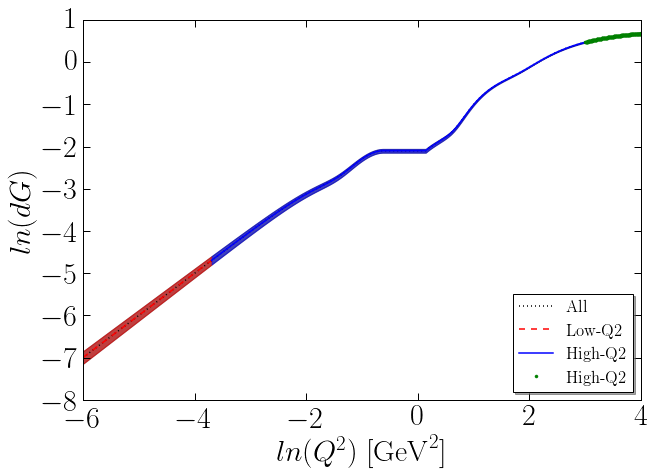

In [14]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(lnQ2, lnGEp_Err, 'k:', color='k',  label='All', linewidth=1.5)
axes.fill_between(lnQ2, lnGEp_Err -lnGEp_DErr, lnGEp_Err+lnGEp_DErr, edgecolor='k',facecolor='k',alpha=0.5)

axes.plot(lnQ2_low, lnGEp_Err_low, 'k--', color='r',  label='Low-Q2', linewidth=1.5)
axes.fill_between(lnQ2_low, lnGEp_Err_low -lnGEp_DErr_low, lnGEp_Err_low+lnGEp_DErr_low, edgecolor='r',facecolor='r',alpha=0.5)

axes.plot(lnQ2_cnt, lnGEp_Err_cnt, 'k-', color='b',  label='High-Q2', linewidth=1.5)
axes.fill_between(lnQ2_cnt, lnGEp_Err_cnt-lnGEp_DErr_cnt, lnGEp_Err_cnt+lnGEp_DErr_cnt, edgecolor='b',facecolor='b',alpha=0.5)

axes.plot(lnQ2_high, lnGEp_Err_high, 'k.', color='g',  label='High-Q2', linewidth=1.5)
axes.fill_between(lnQ2_high, lnGEp_Err_high -lnGEp_DErr_high, lnGEp_Err_high+lnGEp_DErr_high, edgecolor='g',facecolor='g',alpha=0.5)

#axes.set_xlim(1e-6, 1e6)
#axes.set_ylim(1e-8, 1e2)


axes.set_xlabel('$ln(Q^2)$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$ln(dG)$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#plt.savefig('GEp_Error_Curves_precise.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GEp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.png',bbox_inches='tight')

## Define Fitting Functions

In [15]:
##A New Fitting Function
class MyFitter:
    def __init__(self, iter):
        self.iter = iter
    
    def poly1(self, x, par):
        y=np.array([par[j] * x**(j) for j in range(len(par))]).sum()
        return y

    def func(self, params):
        res = []
        chi2=0.0
        for i in range(len(self.X)):
            model = self.poly1(self.X[i],params)
            err = (model-self.Y[i])/self.Err[i]
            chi2 += err*err
            res.append(err)
            self.iter += 1              
        return res
    
    def SetData(self, kX, kY, kErr):
        self.X = kX
        self.Y = kY
        self.Err = kErr
        
    def PrintData(self):
        print 'X = ', self.X
        print 'Y = ',self.Y
    
    def SetIter(self, iter):
        self.iter=iter

## Start Fitting low Q2 region ($<2\times 10^{-4}~GeV^2$)

In [16]:
##### Fitting GEp with a polynomial function #############
import scipy.optimize
import time
tol=1e-13
fitmax0 = 2
tot_low = np.ones(fitmax0)

### Now do the fittingfor GEp
### Define and initialize parameters
fitter_GEp0 = MyFitter(0)
fitter_GEp0.SetData(lnQ2_low, lnGEp_Err_low, lnGEp_DErr_low)

start=time.clock()
GEp_bestfit_low, GEp_cov_low, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GEp0.func, tot_low,full_output=1, ftol=tol)
tot_time = time.clock()-start

GEp_chi2_low = (infodict['fvec'][0:len(lnQ2_low)]**2).sum()
GEp_ndof_low = len(infodict['fvec'])
print 'For GEp low-Q2 Fitting: '
print 'D.O.F = ', GEp_ndof_low
print 'Chi2 = ', GEp_chi2_low
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg

### Now do the fittingfor GMp
### Define and initialize parameters
fitter_GMp0 = MyFitter(0)
fitter_GMp0.SetData(lnQ2_low, lnGMp_Err_low, lnGMp_DErr_low)

start=time.clock()
GMp_bestfit_low, GMp_cov_low, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GMp0.func, tot_low,full_output=1, ftol=tol)
tot_time = time.clock()-start

GMp_chi2_low = (infodict['fvec'][0:len(lnQ2_low)]**2).sum()
GMp_ndof_low = len(infodict['fvec'])
print 'For GMp low-Q2 Fitting: '
print 'D.O.F = ', GMp_ndof_low
print 'Chi2 = ', GMp_chi2_low
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg


For GEp low-Q2 Fitting: 
D.O.F =  461
Chi2 =  0.0051647453735
Total Function Called:  7
Fit Results:  2
Message: The relative error between two consecutive iterates is at most 0.000000
For GMp low-Q2 Fitting: 
D.O.F =  461
Chi2 =  0.00546405819802
Total Function Called:  7
Fit Results:  2
Message: The relative error between two consecutive iterates is at most 0.000000


In [31]:
### Read the output parameters
GEp_parL = GEp_bestfit_low
print GEp_parL
lnGEp_Err_Fit_low=np.array([fitter_GEp0.poly1(lnQ2_low[i], GEp_parL) for i in range(len(lnQ2_low))])
GEp_Err_Fit_Low = 10**lnGEp_Err_Fit_low

GMp_parL = GMp_bestfit_low
print GMp_parL
lnGMp_Err_Fit_low=np.array([fitter_GMp0.poly1(lnQ2_low[i], GMp_parL) for i in range(len(lnQ2_low))])
GMp_Err_Fit_Low = 10**lnGMp_Err_Fit_low

[-1.00096148  0.99898061]
[-0.70102598  0.99900475]


## Start Fitting high Q2 region ($>2\times 10^{-4}~GeV^2$)

In [18]:
##### Fitting GEp with a polynomial function #############
fitmax1 = 2
tot_high = np.ones(fitmax1)

### Now do the fittingfor GEp
### Define and initialize parameters
fitter_GEp1 = MyFitter(0)
fitter_GEp1.SetData(lnQ2_high, lnGEp_Err_high, lnGEp_DErr_high)

start=time.clock()
GEp_bestfit_high, GEp_cov_high, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GEp1.func, tot_high,full_output=1, ftol=tol)
tot_time = time.clock()-start

GEp_chi2_high = (infodict['fvec'][0:len(lnQ2_high)]**2).sum()
GEp_ndof_high = len(infodict['fvec'])
print 'For GEp high-Q2 Fitting: '
print 'D.O.F = ', GEp_ndof_high
print 'Chi2 = ', GEp_chi2_high
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg

### Now do the fittingfor GMp
### Define and initialize parameters
fitter_GMp1 = MyFitter(0)
fitter_GMp1.SetData(lnQ2_high, lnGMp_Err_high, lnGMp_DErr_high)

start=time.clock()
GMp_bestfit_high, GMp_cov_high, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GMp1.func, tot_high,full_output=1, ftol=tol)
tot_time = time.clock()-start

GMp_chi2_high = (infodict['fvec'][0:len(lnQ2_high)]**2).sum()
GMp_ndof_high = len(infodict['fvec'])
print 'For GMp high-Q2 Fitting: '
print 'D.O.F = ', GMp_ndof_high
print 'Chi2 = ', GMp_chi2_high
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg


For GEp high-Q2 Fitting: 
D.O.F =  199
Chi2 =  49.1869995962
Total Function Called:  7
Fit Results:  1
Message: Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
For GMp high-Q2 Fitting: 
D.O.F =  199
Chi2 =  311.177449843
Total Function Called:  10
Fit Results:  2
Message: The relative error between two consecutive iterates is at most 0.000000


In [32]:
### Read the output parameters
GEp_parH = GEp_bestfit_high
print GEp_parH
lnGEp_Err_Fit_high=np.array([fitter_GEp1.poly1(lnQ2_high[i], GEp_parH) for i in range(len(lnQ2_high))])
GEp_Err_Fit_High = 10**lnGEp_Err_Fit_high

GMp_parH = GMp_bestfit_high
print GMp_parH
lnGMp_Err_Fit_high=np.array([fitter_GMp1.poly1(lnQ2_high[i], GMp_parH) for i in range(len(lnQ2_high))])
GMp_Err_Fit_High = 10**lnGMp_Err_Fit_high

[-0.16765541  0.21752229]
[-0.54049485  0.22970965]


## Start Fitting central Q2 region ($2\times 10^{-4}\le Q^2 \le 10^{3}~GeV^2$)

In [20]:
## Replace the first three points with the low-Q2 region points,
## to make sure the fitting go reasonablly at the edge
lnQ2_cnt[0] = lnQ2_low[-1]
lnQ2_cnt[1] = lnQ2_low[-5]
lnQ2_cnt[2] = lnQ2_low[-10]

lnGEp_Err_cnt[0] = lnGEp_Err_low[-1]
lnGEp_Err_cnt[1] = lnGEp_Err_low[-5]
lnGEp_Err_cnt[2] = lnGEp_Err_low[-10]
lnGEp_DErr_cnt[0] = 1e-5
lnGEp_DErr_cnt[1] = 0.001
lnGEp_DErr_cnt[2] = 0.001

lnGMp_Err_cnt[0] = lnGMp_Err_low[-1]
lnGMp_Err_cnt[1] = lnGMp_Err_low[-5]
lnGMp_Err_cnt[2] = lnGMp_Err_low[-10]
lnGMp_DErr_cnt[0] = 1e-5
lnGMp_DErr_cnt[1] = 0.001
lnGMp_DErr_cnt[2] = 0.001

## Replace the first three points with the low-Q2 region points,
## to make sure the fitting go reasonablly at the edge
lnQ2_cnt[-1] = lnQ2_high[1]
lnQ2_cnt[-2] = lnQ2_high[5]
lnQ2_cnt[-3] = lnQ2_high[10]

lnGEp_Err_cnt[-1] = lnGEp_Err_high[1]
lnGEp_Err_cnt[-2] = lnGEp_Err_high[5]
lnGEp_Err_cnt[-3] = lnGEp_Err_high[10]
lnGEp_DErr_cnt[-1] = 1e-5
lnGEp_DErr_cnt[-2] = 0.001
lnGEp_DErr_cnt[-3] = 0.001

lnGMp_Err_cnt[-1] = lnGMp_Err_high[1]
lnGMp_Err_cnt[-2] = lnGMp_Err_high[5]
lnGMp_Err_cnt[-3] = lnGMp_Err_high[10]
lnGMp_DErr_cnt[-1] = 1e-5
lnGMp_DErr_cnt[-2] = 0.001
lnGMp_DErr_cnt[-3] = 0.001

In [81]:
fitmax2 = 20
tot_cnt = np.ones(fitmax2)

In [82]:
### First, Add the last 3 points with tiny errors from the low-Q2 fit to make sure the linear behavior at low-Q2
##### Fitting GEp with a polynomial function #############
fitter_GEp2 = MyFitter(0)
fitter_GEp2.SetData(lnQ2_cnt, lnGEp_Err_cnt, lnGEp_DErr_cnt)

### Now do the fitting
start=time.clock()
GEp_bestfit_cnt, GEp_cov_cnt, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GEp2.func, tot_cnt,full_output=1, ftol=tol)
tot_time = time.clock()-start

GEp_chi2_cnt = (infodict['fvec'][0:len(lnQ2_cnt)]**2).sum()
GEp_ndof_cnt = len(infodict['fvec'])
print 'For GEp high-Q2 Fitting: '
print 'D.O.F = ', GEp_ndof_cnt
print 'Chi2 = ', GEp_chi2_cnt
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg


##### Fitting GEp with a polynomial function #############
fitter_GMp2 = MyFitter(0)
fitter_GMp2.SetData(lnQ2_cnt, lnGMp_Err_cnt, lnGMp_DErr_cnt)

### Now do the fitting
start=time.clock()
GMp_bestfit_cnt, GMp_cov_cnt, infodict, mesg, ier = scipy.optimize.leastsq(fitter_GMp2.func, tot_cnt,full_output=1, ftol=tol)
tot_time = time.clock()-start

GMp_chi2_cnt = (infodict['fvec'][0:len(lnQ2_cnt)]**2).sum()
GMp_ndof_cnt = len(infodict['fvec'])
print 'For GMp high-Q2 Fitting: '
print 'D.O.F = ', GMp_ndof_cnt
print 'Chi2 = ', GMp_chi2_cnt
#print 'Total Time Used:', tot_time
print 'Total Function Called: ', infodict['nfev']
print 'Fit Results: ', ier
print 'Message:', mesg

For GEp high-Q2 Fitting: 
D.O.F =  1340
Chi2 =  105.03588991
Total Function Called:  434
Fit Results:  2
Message: The relative error between two consecutive iterates is at most 0.000000
For GMp high-Q2 Fitting: 
D.O.F =  1340
Chi2 =  560.023633311
Total Function Called:  374
Fit Results:  2
Message: The relative error between two consecutive iterates is at most 0.000000


In [83]:
### Read the output parameters
GEp_parC = GEp_bestfit_cnt
print GEp_parC
lnGEp_Err_Fit_cnt=np.array([fitter_GEp2.poly1(lnQ2_cnt[i], GEp_parC) for i in range(len(lnQ2_cnt))])

lnGEp_Err_Fit_cnt_full=np.array([fitter_GEp2.poly1(lnQ2[i], GEp_parC) for i in range(len(lnQ2))])
GEp_Err_New=np.array([10**(fitter_GEp2.poly1(lnQ2[i], GEp_parC)) for i in range(len(lnQ2))])

GMp_parC = GMp_bestfit_cnt
print GMp_parC
lnGMp_Err_Fit_cnt=np.array([fitter_GMp2.poly1(lnQ2_cnt[i], GMp_parC) for i in range(len(lnQ2_cnt))])

lnGMp_Err_Fit_cnt_full=np.array([fitter_GMp2.poly1(lnQ2[i], GMp_parC) for i in range(len(lnQ2))])
GMp_Err_New=np.array([10**(fitter_GMp2.poly1(lnQ2[i], GMp_parC)) for i in range(len(lnQ2))])

[ -2.10091500e+00   1.06818635e-01   7.22819480e-01   8.86484028e-01
  -2.31434378e-01  -4.37998495e-01  -1.35731321e-01   8.77315476e-02
   1.20944010e-01   1.63831043e-03  -3.82751510e-02  -4.41461125e-03
   6.43828739e-03   9.59394177e-04  -6.12395685e-04  -1.01868615e-04
   3.11891648e-05   5.58522832e-06  -6.63281924e-07  -1.26329066e-07]
[ -2.07097546e+00   1.87050267e-01  -7.78844599e-01  -2.26805282e-01
   7.77596431e-01   2.79059342e-01  -2.56893197e-01  -7.94643253e-02
   3.43121536e-02   5.61302904e-03   4.85766939e-04   1.52248292e-03
  -7.40237529e-04  -3.93962234e-04   9.47892897e-05   3.92886943e-05
  -5.22967551e-06  -1.89774442e-06   1.10759338e-07   3.67501096e-08]


/Users/yez/Library/Python/2.7/lib/python/site-packages/ipykernel/__main__.py:7: RuntimeWarning: overflow encountered in double_scalars


## Save Fitting Results

In [84]:
## Save parameters

of = open('proton_fit_par%d.dat'%fitmax2,'w')

print >>of, '======= GEp ======'
print >>of, ' Low-Q2: ', GEp_parL
print >>of, ' Mid-Q2: ', GEp_parC 
print >>of, 'High-Q2: ', GEp_parH 
print >>of, ''
print >>of, '======= GMp ======'
print >>of, ' Low-Q2: ', GMp_parL
print >>of, ' Mid-Q2: ', GMp_parC 
print >>of, 'High-Q2: ', GMp_parH 
of.close()

## Check Fitting Results

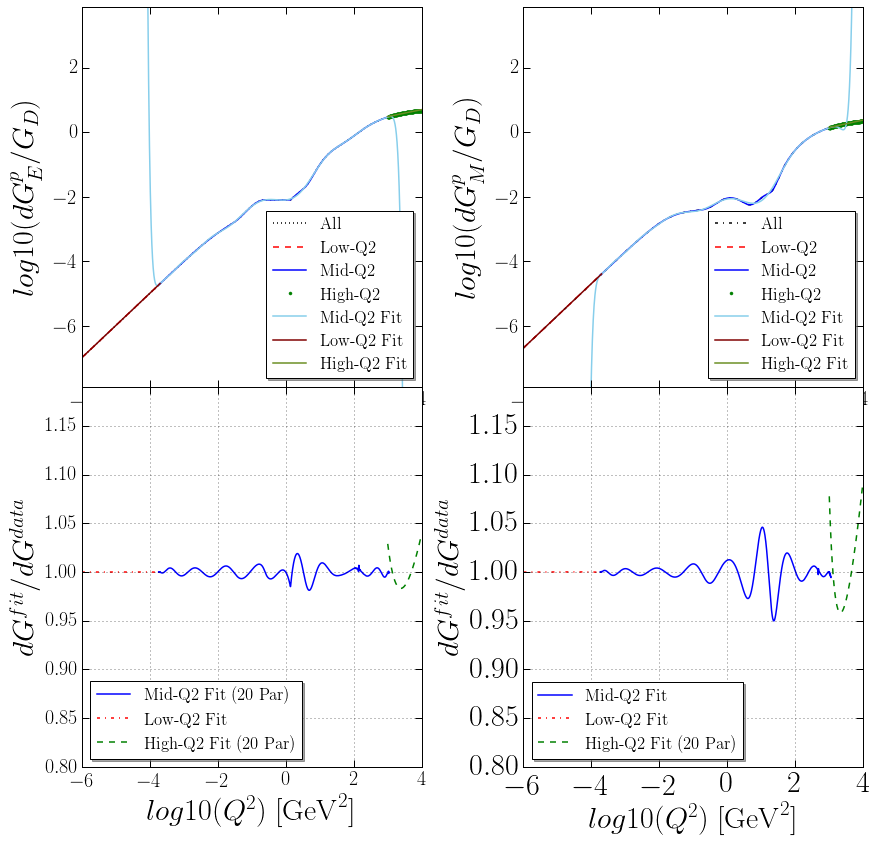

In [85]:
f1, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0, wspace=0.3)

#######  Subplot for GE/GD.
axes[0][0].plot(lnQ2, lnGEp_Err, 'k:', color='k',  label='All', linewidth=1.5)
#axes[0][0].fill_between(lnQ2, lnGEp_Err -lnGEp_DErr, lnGEp_Err+lnGEp_DErr, edgecolor='k',facecolor='k',alpha=0.5)

axes[0][0].plot(lnQ2_low, lnGEp_Err_low, 'k--', color='r',  label='Low-Q2', linewidth=1.5)
#axes[0][0].fill_between(lnQ2_low, lnGEp_Err_Fit_low -lnGEp_DErr_low, lnGEp_Err_low+lnGEp_DErr_low, edgecolor='r',facecolor='r',alpha=0.5)

axes[0][0].plot(lnQ2_cnt, lnGEp_Err_cnt, 'k-', color='b',  label='Mid-Q2', linewidth=1.5)
#axes[0][0].fill_between(lnQ2_cnt, lnGEp_Err_Fit_cnt -lnGEp_DErr_cnt, lnGEp_Err_cnt+lnGEp_DErr_cnt, edgecolor='b',facecolor='b',alpha=0.5)

axes[0][0].plot(lnQ2_high, lnGEp_Err_high, 'k.', color='g',  label='High-Q2', linewidth=1.5)
#axes[0][0].fill_between(lnQ2_high, lnGEp_Err_Fit_high -lnGEp_DErr_high, lnGEp_Err_high+lnGEp_DErr_high, edgecolor='g',facecolor='g',alpha=0.5)

axes[0][0].plot(lnQ2, lnGEp_Err_Fit_cnt_full, 'k-', color='skyblue',  label='Mid-Q2 Fit', linewidth=1.5)
axes[0][0].plot(lnQ2_low, lnGEp_Err_Fit_low, 'k-', color='maroon',  label='Low-Q2 Fit', linewidth=1.5)
axes[0][0].plot(lnQ2_high, lnGEp_Err_Fit_high, 'k-', color='olivedrab',  label='High-Q2 Fit', linewidth=1.5)

axes[0][0].set_xlabel('$log10(Q^2)$ $[\mathrm{GeV}^2]$', fontsize=30)
axes[0][0].set_ylabel('$log10(dG_E^p/G_D)$', fontsize=30)
axes[0][0].set_xlim(-6, 4)
axes[0][0].set_ylim(-7.9, 3.9)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes[0][0].legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes[0][0].xaxis.set_tick_params(width=1, length=7)
axes[0][0].yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#######  Subplot for Ratio of Fit vs Data
axes[1][0].plot(lnQ2_cnt, lnGEp_Err_Fit_cnt/lnGEp_Err_cnt, 'k-', color='b',  label='Mid-Q2 Fit (%d Par)'%fitmax2, linewidth=1.5)
axes[1][0].plot(lnQ2_low, lnGEp_Err_Fit_low/lnGEp_Err_low, 'k-.', color='r',  label='Low-Q2 Fit', linewidth=1.5)
axes[1][0].plot(lnQ2_high, lnGEp_Err_Fit_high/lnGEp_Err_high, 'k--', color='g',  label='High-Q2 Fit (%d Par)'%fitmax2, linewidth=1.5)

axes[1][0].set_xlabel('$log10(Q^2)$ $[\mathrm{GeV}^2]$', fontsize=30)
axes[1][0].set_ylabel('$dG^{fit}/dG^{data}$', fontsize=30)
axes[1][0].set_xlim(-6, 4)
axes[1][0].set_ylim(0.8, 1.19)
axes[1][0].grid()

lg1= axes[1][0].legend(loc='lower left', shadow='true', fontsize='small', numpoints=1)
axes[1][0].xaxis.set_tick_params(width=1, length=7)
axes[1][0].yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)



#######  Subplot for GE/GD.
axes[0][1].plot(lnQ2, lnGMp_Err, 'k-.', color='k',  label='All', linewidth=1.5)
#axes[0][1].fill_between(lnQ2, lnGMp_Err -lnGMp_DErr, lnGMp_Err+lnGMp_DErr, edgecolor='k',facecolor='k',alpha=0.5)

axes[0][1].plot(lnQ2_low, lnGMp_Err_low, 'k--', color='r',  label='Low-Q2', linewidth=1.5)
#axes[0][1].fill_between(lnQ2_low, lnGMp_Err_Fit_low -lnGMp_DErr_low, lnGMp_Err_low+lnGMp_DErr_low, edgecolor='r',facecolor='r',alpha=0.5)


axes[0][1].plot(lnQ2_cnt, lnGMp_Err_cnt, 'k-', color='b',  label='Mid-Q2', linewidth=1.5)
#axes[0][1].fill_between(lnQ2_cnt, lnGMp_Err_Fit_cnt -lnGMp_DErr_cnt, lnGMp_Err_cnt+lnGMp_DErr_cnt, edgecolor='b',facecolor='b',alpha=0.5)

axes[0][1].plot(lnQ2_high, lnGMp_Err_high, 'k.', color='g',  label='High-Q2', linewidth=1.5)
#axes[0][1].fill_between(lnQ2_high, lnGMp_Err_Fit_high -lnGMp_DErr_high, lnGMp_Err_high+lnGMp_DErr_high, edgecolor='g',facecolor='g',alpha=0.5)

axes[0][1].plot(lnQ2, lnGMp_Err_Fit_cnt_full, 'k-', color='skyblue',  label='Mid-Q2 Fit', linewidth=1.5)
axes[0][1].plot(lnQ2_low, lnGMp_Err_Fit_low, 'k-', color='maroon',  label='Low-Q2 Fit', linewidth=1.5)
axes[0][1].plot(lnQ2_high, lnGMp_Err_Fit_high, 'k-', color='olivedrab',  label='High-Q2 Fit', linewidth=1.5)

axes[0][1].set_xlabel('$log10(Q^2)$ $[\mathrm{GeV}^2]$', fontsize=30)
axes[0][1].set_ylabel('$log10(dG_M^p/G_D)$', fontsize=30)
axes[0][1].set_xlim(-6, 4)
axes[0][1].set_ylim(-7.9, 3.9)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes[0][1].legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes[0][1].xaxis.set_tick_params(width=1, length=7)
axes[0][1].yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#######  Subplot for Ratio of Fit vs Data
axes[1][1].plot(lnQ2_cnt, lnGMp_Err_Fit_cnt/lnGMp_Err_cnt, 'k-', color='b',  label='Mid-Q2 Fit', linewidth=1.5)
axes[1][1].plot(lnQ2_low, lnGMp_Err_Fit_low/lnGMp_Err_low, 'k-.', color='r',  label='Low-Q2 Fit', linewidth=1.5)
axes[1][1].plot(lnQ2_high, lnGMp_Err_Fit_high/lnGMp_Err_high, 'k--', color='g',  label='High-Q2 Fit (%d Par)'%fitmax2, linewidth=1.5)

axes[1][1].set_xlabel('$log10(Q^2)$ $[\mathrm{GeV}^2]$', fontsize=30)
axes[1][1].set_ylabel('$dG^{fit}/dG^{data}$', fontsize=30)
axes[1][1].set_xlim(-6, 4)
axes[1][1].set_ylim(0.8, 1.19)
axes[1][1].grid()

lg1= axes[1][1].legend(loc='lower left', shadow='true', fontsize='small', numpoints=1)
axes[1][1].xaxis.set_tick_params(width=1, length=7)
axes[1][1].yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GEpGMp_NewPar_%d.pdf'%fitmax2,bbox_inches='tight')

# Plot Errors

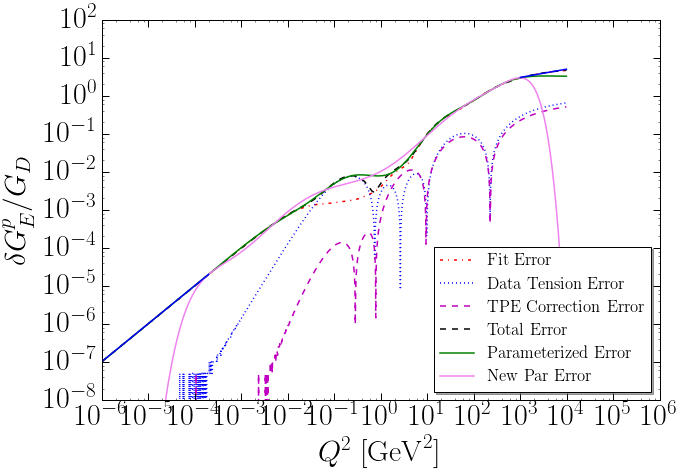

In [59]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GE_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GE_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GE_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GE_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)
axes.plot(Q2, GEp_Err_New, 'k-', color='violet',  label='New Par Error', linewidth=1.5)
axes.plot(10**lnQ2_low, GEp_Err_Fit_Low, 'k-', color='b',  linewidth=1.5)
axes.plot(10**lnQ2_high, GEp_Err_Fit_High, 'k-', color='b',  linewidth=1.5)

axes.set_xlim(1e-6, 1e6)
axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^p/G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GEp_Error_Curves_precise.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GEp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.png',bbox_inches='tight')

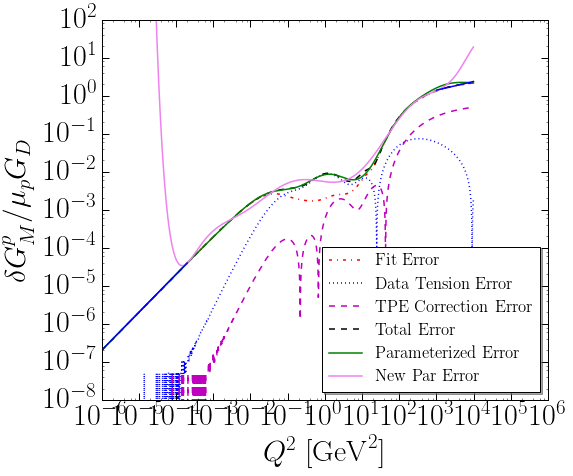

In [60]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD
axes.plot(Q2, GM_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GM_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GM_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GM_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GM_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)
axes.plot(Q2, GMp_Err_New, 'k-', color='violet',  label='New Par Error', linewidth=1.5)
axes.plot(10**lnQ2_low, GMp_Err_Fit_Low, 'k-', color='b',  linewidth=1.5)
axes.plot(10**lnQ2_high, GMp_Err_Fit_High, 'k-', color='b',  linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
axes.set_ylim(1e-4, 1)
axes.set_xlim(1e-6, 1e6)
axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^p/\mu_p G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GMp_Error_Curves_precise.pdf',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves.eps',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GMp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.png',bbox_inches='tight')axes.plot(Q2, GE_Err_New, 'k-', color='pink',  label='New Par Error', linewidth=1.5)
